# Regression in Python

***
This is a very quick run-through of some basic statistical concepts, adapted from [Lab 4 in Harvard's CS109](https://github.com/cs109/2015lab4) course. Please feel free to try the original lab if you're feeling ambitious :-) The CS109 git repository also has the solutions if you're stuck.

* Linear Regression Models
* Prediction using linear regression

Linear regression is used to model and predict continuous outcomes with normal random errors. There are nearly an infinite number of different types of regression models and each regression model is typically defined by the distribution of the prediction errors (called "residuals") of the type of data. Logistic regression is used to model binary outcomes whereas Poisson regression is used to predict counts. In this exercise, we'll see some examples of linear regression as well as Train-test splits.

The packages we'll cover are: `statsmodels`, `seaborn`, and `scikit-learn`. While we don't explicitly teach `statsmodels` and `seaborn` in the Springboard workshop, those are great libraries to know.
***

<img width=600 height=300 src="https://imgs.xkcd.com/comics/sustainable.png"/>
***

In [1]:
# special IPython command to prepare the notebook for matplotlib and other libraries
%matplotlib inline 

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn

import seaborn as sns

# special matplotlib argument for improved plots
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")


***
# Part 1: Introduction to Linear Regression
### Purpose of linear regression
***
<div class="span5 alert alert-info">

<p> Given a dataset containing predictor variables $X$ and outcome/response variable $Y$, linear regression can be used to: </p>
<ul>
  <li> Build a <b>predictive model</b> to predict future values of $\hat{Y}$, using new data $X^*$ where $Y$ is unknown.</li>
  <li> Model the <b>strength of the relationship</b> between each independent variable $X_i$ and $Y$</li>
    <ul>
      <li> Many times, only a subset of independent variables $X_i$ will have a linear relationship with $Y$</li>
      <li> Need to figure out which $X_i$ contributes most information to predict $Y$ </li>
    </ul>
   <li>It is in many cases, the first pass prediction algorithm for continuous outcomes. </li>
</ul>
</div>

### A Brief Mathematical Recap
***

[Linear Regression](http://en.wikipedia.org/wiki/Linear_regression) is a method to model the relationship between a set of independent variables $X$ (also knowns as explanatory variables, features, predictors) and a dependent variable $Y$.  This method assumes the relationship between each predictor $X$ is **linearly** related to the dependent variable $Y$. The most basic linear regression model contains one independent variable $X$, we'll call this the simple model. 

$$ Y = \beta_0 + \beta_1 X + \epsilon$$

where $\epsilon$ is considered as an unobservable random variable that adds noise to the linear relationship. In linear regression, $\epsilon$ is assumed to be normally distributed with a mean of 0. In other words, what this means is that on average, if we know $Y$, a roughly equal number of predictions $\hat{Y}$ will be above $Y$ and others will be below $Y$. That is, on average, the error is zero. The residuals, $\epsilon$ are also assumed to be "i.i.d.": independently and identically distributed. Independence means that the residuals are not correlated -- the residual from one prediction has no effect on the residual from another prediction. Correlated errors are common in time series analysis and spatial analyses.

* $\beta_0$ is the intercept of the linear model and represents the average of $Y$ when all independent variables $X$ are set to 0.

* $\beta_1$ is the slope of the line associated with the regression model and represents the average effect of a one-unit increase in $X$ on $Y$.

* Back to the simple model. The model in linear regression is the *conditional mean* of $Y$ given the values in $X$ is expressed a linear function.  

$$ y = f(x) = E(Y | X = x)$$ 

![conditional mean](images/conditionalmean.png)
*Image from http://www.learner.org/courses/againstallodds/about/glossary.html. Note this image uses $\alpha$ and $\beta$ instead of $\beta_0$ and $\beta_1$.*

* The goal is to estimate the coefficients (e.g. $\beta_0$ and $\beta_1$). We represent the estimates of the coefficients with a "hat" on top of the letter.  

$$ \hat{\beta}_0, \hat{\beta}_1 $$

* Once we estimate the coefficients $\hat{\beta}_0$ and $\hat{\beta}_1$, we can use these to predict new values of $Y$ given new data $X$.

$$\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x_1$$

* Multiple linear regression is when you have more than one independent variable and the estimation involves matrices
    * $X_1$, $X_2$, $X_3$, $\ldots$


* How do you estimate the coefficients? 
    * There are many ways to fit a linear regression model
    * The method called **least squares** is the most common methods
    * We will discuss least squares

$$ Y = \beta_0 + \beta_1 X_1 + \ldots + \beta_p X_p + \epsilon$$ 
    
### Estimating $\hat\beta$: Least squares
***
[Least squares](http://en.wikipedia.org/wiki/Least_squares) is a method that can estimate the coefficients of a linear model by minimizing the squared residuals: 

$$ \mathscr{L} = \sum_{i=1}^N \epsilon_i^2 = \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2  = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2 $$

where $N$ is the number of observations and $\epsilon$ represents a residual or error, ACTUAL - PREDICTED.  

#### Estimating the intercept $\hat{\beta_0}$ for the simple linear model

We want to minimize the squared residuals and solve for $\hat{\beta_0}$ so we take the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta_0}$ 

$
\begin{align}
\frac{\partial \mathscr{L}}{\partial \hat{\beta_0}} &= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \epsilon^2 \\
&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\
&= \frac{\partial}{\partial \hat{\beta_0}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\
&= -2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \hspace{25mm} \mbox{(by chain rule)} \\
&= -2 \sum_{i=1}^N (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i) \\
&= -2 \left[ \left( \sum_{i=1}^N y_i \right) - N \hat{\beta_0} - \hat{\beta}_1 \left( \sum_{i=1}^N x_i
\right) \right] \\
& 2 \left[ N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i \right] = 0 \hspace{20mm} \mbox{(Set equal to 0 and solve for $\hat{\beta}_0$)} \\
& N \hat{\beta}_0 + \hat{\beta}_1 \sum_{i=1}^N x_i - \sum_{i=1}^N y_i = 0 \\
& N \hat{\beta}_0 = \sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i \\
& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i - \hat{\beta}_1 \sum_{i=1}^N x_i}{N} \\
& \hat{\beta}_0 = \frac{\sum_{i=1}^N y_i}{N} - \hat{\beta}_1 \frac{\sum_{i=1}^N x_i}{N} \\
& \boxed{\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}}
\end{align}
$

Using this new information, we can compute the estimate for $\hat{\beta}_1$ by taking the partial derivative of $\mathscr{L}$ with respect to $\hat{\beta}_1$.

$
\begin{align}
\frac{\partial \mathscr{L}}{\partial \hat{\beta_1}} &= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \epsilon^2 \\
&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \hat{y}_i \right)^2 \\
&= \frac{\partial}{\partial \hat{\beta_1}} \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right)^2 \\
&= 2 \sum_{i=1}^N \left( y_i - \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) \right) \left( -x_i \right) \hspace{25mm}\mbox{(by chain rule)} \\
&= -2 \sum_{i=1}^N x_i \left( y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i \right) \\
&= -2 \sum_{i=1}^N x_i (y_i - \hat{\beta}_0 x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \sum_{i=1}^N x_i (y_i - \left( \bar{y} - \hat{\beta}_1 \bar{x} \right) x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \sum_{i=1}^N (x_i y_i - \bar{y}x_i + \hat{\beta}_1\bar{x}x_i - \hat{\beta}_1 x_i^2) \\
&= -2 \left[ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i + \hat{\beta}_1\bar{x}\sum_{i=1}^N x_i - \hat{\beta}_1 \sum_{i=1}^N x_i^2 \right] \\
&= -2 \left[ \hat{\beta}_1 \left\{ \bar{x} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i^2 \right\} + \left\{ \sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i \right\}\right] \\
& 2 \left[ \hat{\beta}_1 \left\{ \sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i \right\} + \left\{ \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right\} \right] = 0 \\
& \hat{\beta}_1 = \frac{-\left( \bar{y} \sum_{i=1}^N x_i - \sum_{i=1}^N x_i y_i \right)}{\sum_{i=1}^N x_i^2 - \bar{x}\sum_{i=1}^N x_i} \\
&= \frac{\sum_{i=1}^N x_i y_i - \bar{y} \sum_{i=1}^N x_i}{\sum_{i=1}^N x_i^2 - \bar{x} \sum_{i=1}^N x_i} \\
& \boxed{\hat{\beta}_1 = \frac{\sum_{i=1}^N x_i y_i - \bar{x}\bar{y}n}{\sum_{i=1}^N x_i^2 - n \bar{x}^2}}
\end{align}
$

The solution can be written in compact matrix notation as

$$\hat\beta =  (X^T X)^{-1}X^T Y$$ 

We wanted to show you this in case you remember linear algebra, in order for this solution to exist we need $X^T X$ to be invertible. Of course this requires a few extra assumptions, $X$ must be full rank so that $X^T X$ is invertible, etc. Basically, $X^T X$ is full rank if all rows and columns are linearly independent. This has a loose relationship to variables and observations being independent respective. **This is important for us because this means that having redundant features in our regression models will lead to poorly fitting (and unstable) models.** We'll see an implementation of this in the extra linear regression example.

***
# Part 2: Exploratory Data Analysis for Linear Relationships

The [Boston Housing data set](https://archive.ics.uci.edu/ml/datasets/Housing) contains information about the housing values in suburbs of Boston.  This dataset was originally taken from the StatLib library which is maintained at Carnegie Mellon University and is now available on the UCI Machine Learning Repository. 


## Load the Boston Housing data set from `sklearn`
***

This data set is available in the [sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_boston.html#sklearn.datasets.load_boston) python module which is how we will access it today.  

In [2]:
import pandas as pd

bos = pd.read_csv('boston.csv')
print(bos.shape)
bos.head()

(506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,1.689365,26.601312,14.064366,0,0.656070,5.830959,75.605572,6.285337,24,638.167335,17.972353,355.329277,14.148797,9.712413
1,10.836437,19.018940,12.533045,0,0.398866,6.621511,97.966986,1.326114,6,187.000000,19.438080,192.210791,10.766932,15.749803
2,4.740284,32.909124,12.973894,0,0.569660,7.543044,72.671348,7.301171,8,447.533418,17.017512,296.034785,15.493298,21.166468
3,3.286593,14.229644,2.290435,0,0.779916,6.146367,69.271676,6.998801,6,317.262680,16.678253,182.646400,10.849624,15.391853
4,0.610650,10.454444,3.640710,0,0.438962,6.783831,58.725260,5.344806,2,428.858307,18.980029,395.849671,27.059073,5.743239


Now we have a pandas DataFrame called `bos` containing all the data we want to use to predict Boston Housing prices.  Let's rename the target variable of `MEDV` to `PRICE` which will contain the prices. 

In [3]:
bos = bos.rename(columns={"MEDV":"PRICE"})
bos.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,1.689365,26.601312,14.064366,0,0.656070,5.830959,75.605572,6.285337,24,638.167335,17.972353,355.329277,14.148797,9.712413
1,10.836437,19.018940,12.533045,0,0.398866,6.621511,97.966986,1.326114,6,187.000000,19.438080,192.210791,10.766932,15.749803
2,4.740284,32.909124,12.973894,0,0.569660,7.543044,72.671348,7.301171,8,447.533418,17.017512,296.034785,15.493298,21.166468
3,3.286593,14.229644,2.290435,0,0.779916,6.146367,69.271676,6.998801,6,317.262680,16.678253,182.646400,10.849624,15.391853
4,0.610650,10.454444,3.640710,0,0.438962,6.783831,58.725260,5.344806,2,428.858307,18.980029,395.849671,27.059073,5.743239


## EDA and Summary Statistics
***

Let's explore this data set.  First we use `describe()` to get basic summary statistics for each of the columns. 

In [4]:
bos.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.610698,10.451345,11.983404,0.067194,0.558305,6.305313,65.563862,4.037644,6.276680,408.833792,18.441503,331.072727,12.912265,13.436586
std,3.491683,10.781308,6.561882,0.250605,0.104906,0.678677,24.869913,2.006422,6.167507,147.003509,1.982121,71.744804,7.112607,5.757364
min,0.018268,0.051071,0.460000,0.000000,0.385000,4.434977,2.900000,1.130000,1.000000,187.000000,12.600000,29.663505,1.730000,5.000000
25%,0.996998,2.870837,7.256782,0.000000,0.482825,5.820521,49.641176,2.296784,2.000000,294.409421,17.091819,289.259359,7.565124,8.829362
50%,2.606976,7.088075,11.936034,0.000000,0.554473,6.319535,66.034175,3.957871,5.000000,397.212888,18.388836,351.936357,12.602196,12.997946
75%,5.067792,14.479780,16.146573,0.000000,0.629044,6.759942,84.846715,5.432733,7.000000,521.696312,19.790317,396.900000,17.398648,17.500076
max,17.844583,89.896902,27.740000,1.000000,0.871000,8.456943,100.000000,9.823646,24.000000,711.000000,22.000000,396.900000,35.784594,33.572744


### Scatterplots
***

Let's look at some scatter plots for three variables: 'CRIM' (per capita crime rate), 'RM' (number of rooms) and 'PTRATIO' (pupil-to-teacher ratio in schools).  

In [5]:
plt.scatter(bos.CRIM, bos.PRICE)
plt.xlabel("Per capita crime rate by town (CRIM)")
plt.ylabel("Housing Price")
plt.title("Relationship between CRIM and Price")

Text(0.5, 1.0, 'Relationship between CRIM and Price')

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> What kind of relationship do you see? e.g. positive, negative?  linear? non-linear? Is there anything else strange or interesting about the data? What about outliers?</p>


<p><b>Exercise:</b> Create scatter plots between *RM* and *PRICE*, and *PTRATIO* and *PRICE*. Label your axes appropriately using human readable labels. Tell a story about what you see.</p>

<p><b>Exercise:</b> What are some other numeric variables of interest? Why do you think they are interesting? Plot scatterplots with these variables and *PRICE* (house price) and tell a story about what you see.</p>

</div>

**Relationship between CRIM and PRICE:**

The scatter plot shows a **negative, non-linear** relationship between crime rate and housing price. The vast majority of towns have low crime rates with a wide spread of prices, but as crime increases, prices drop quite sharply. The relationship looks more like an exponential decay than a straight line. There are also a handful of extreme **outliers** at the high-crime end of the x-axis that stand out clearly.

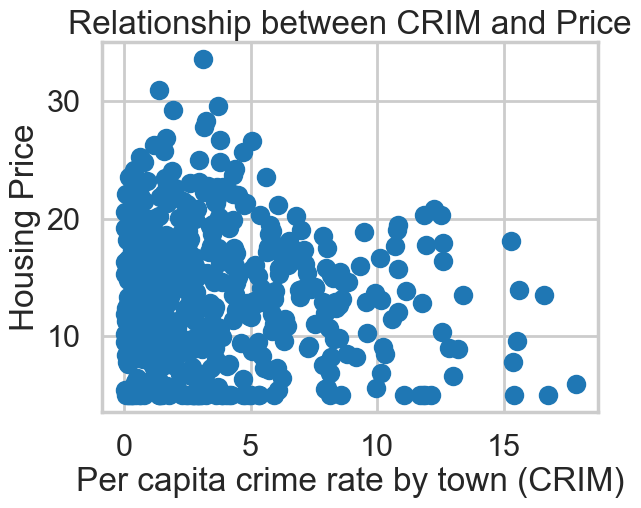

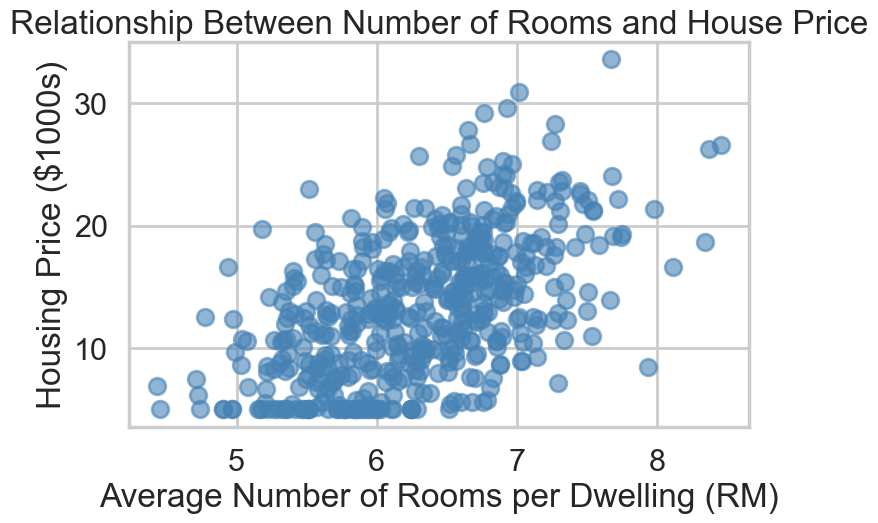

In [6]:
# Scatter plot: RM (number of rooms) vs PRICE
plt.figure(figsize=(8, 5))
plt.scatter(bos.RM, bos.PRICE, alpha=0.6, color='steelblue')
plt.xlabel('Average Number of Rooms per Dwelling (RM)')
plt.ylabel('Housing Price ($1000s)')
plt.title('Relationship Between Number of Rooms and House Price')
plt.show()

**RM vs PRICE:** Clear **positive, roughly linear** relationship — more rooms = higher price. This is probably the strongest and cleanest single predictor we've seen so far. There are a few homes with very high prices that sit above the trend, but overall the pattern is consistent.

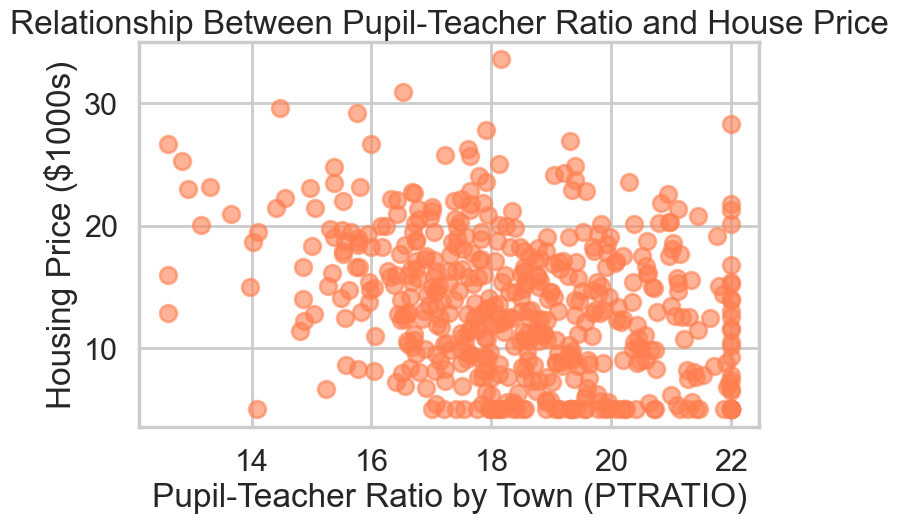

In [7]:
# Scatter plot: PTRATIO (pupil-teacher ratio) vs PRICE
plt.figure(figsize=(8, 5))
plt.scatter(bos.PTRATIO, bos.PRICE, alpha=0.6, color='coral')
plt.xlabel('Pupil-Teacher Ratio by Town (PTRATIO)')
plt.ylabel('Housing Price ($1000s)')
plt.title('Relationship Between Pupil-Teacher Ratio and House Price')
plt.show()

**PTRATIO vs PRICE:** **Negative** relationship — towns with higher pupil-teacher ratios (more students per teacher, i.e. worse schools) tend to have lower housing prices. The relationship has a lot of scatter and is not perfectly linear, but the downward trend is clear. This makes intuitive sense: families pay a premium to live near good schools.

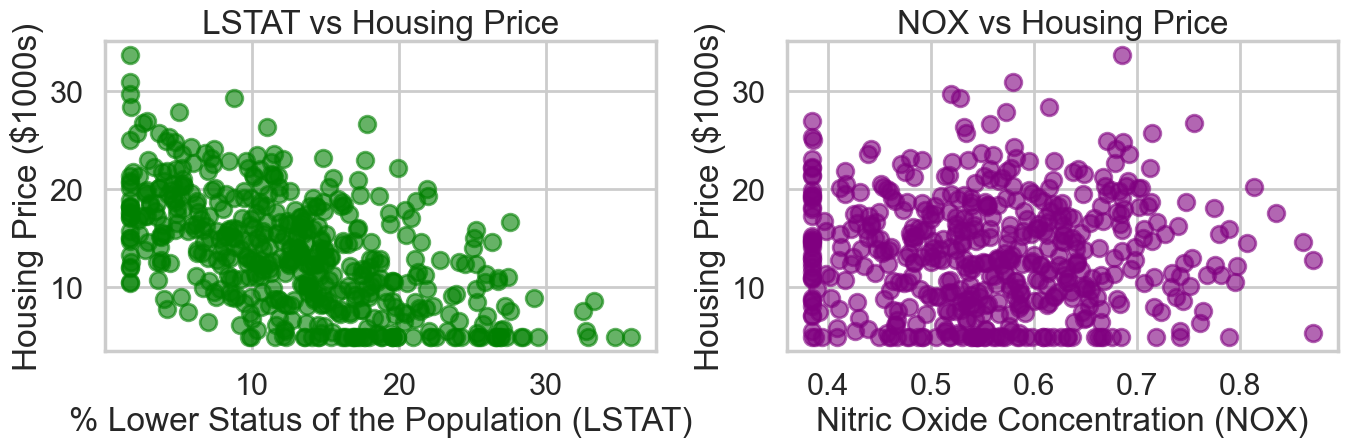

In [8]:
# Two other interesting variables: LSTAT and NOX
# LSTAT = % lower status of population (proxy for income/wealth in the area)
# NOX = nitric oxide concentration (air pollution - affects neighbourhood desirability)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(bos.LSTAT, bos.PRICE, alpha=0.6, color='green')
axes[0].set_xlabel('% Lower Status of the Population (LSTAT)')
axes[0].set_ylabel('Housing Price ($1000s)')
axes[0].set_title('LSTAT vs Housing Price')

axes[1].scatter(bos.NOX, bos.PRICE, alpha=0.6, color='purple')
axes[1].set_xlabel('Nitric Oxide Concentration (NOX)')
axes[1].set_ylabel('Housing Price ($1000s)')
axes[1].set_title('NOX vs Housing Price')

plt.tight_layout()
plt.show()

**LSTAT vs PRICE:** Strong **negative** relationship — as the percentage of lower-status residents increases, housing prices fall significantly. This is one of the strongest predictors in the dataset and makes socioeconomic sense: wealthier areas command higher property values.

**NOX vs PRICE:** Also a **negative** relationship — more air pollution corresponds to lower prices. People clearly pay a premium to live in cleaner, less polluted neighbourhoods. The relationship is noisier than LSTAT but the trend is still visible.

### Scatterplots using Seaborn
***

[Seaborn](https://stanford.edu/~mwaskom/software/seaborn/) is a cool Python plotting library built on top of matplotlib. It provides convenient syntax and shortcuts for many common types of plots, along with better-looking defaults.

We can also use [seaborn regplot](https://stanford.edu/~mwaskom/software/seaborn/tutorial/regression.html#functions-to-draw-linear-regression-models) for the scatterplot above. This provides automatic linear regression fits (useful for data exploration later on). Here's one example below.

In [9]:
sns.regplot(y="PRICE", x="RM", data=bos, fit_reg = True)

<Axes: xlabel='RM', ylabel='PRICE'>

### Histograms
***


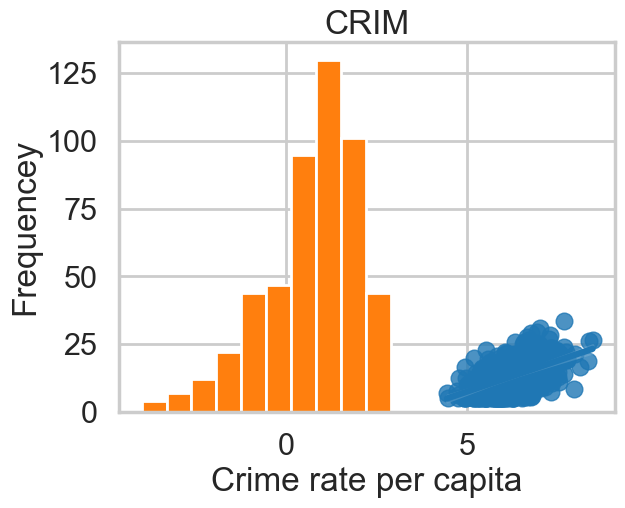

In [10]:
plt.hist(np.log(bos.CRIM))
plt.title("CRIM")
plt.xlabel("Crime rate per capita")
plt.ylabel("Frequencey")
plt.show()

<div class="span5 alert alert-info">
<h3>Part 2 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> In the above histogram, we took the logarithm of the crime rate per capita. Repeat this histogram without taking the log. What was the purpose of taking the log? What do we gain by making this transformation? What do you now notice about this variable that is not obvious without making the transformation?

<p><b>Exercise:</b> Plot the histogram for *RM* and *PTRATIO* against each other, along with the two variables you picked in the previous section. We are looking for correlations in predictors here.</p>
</div>

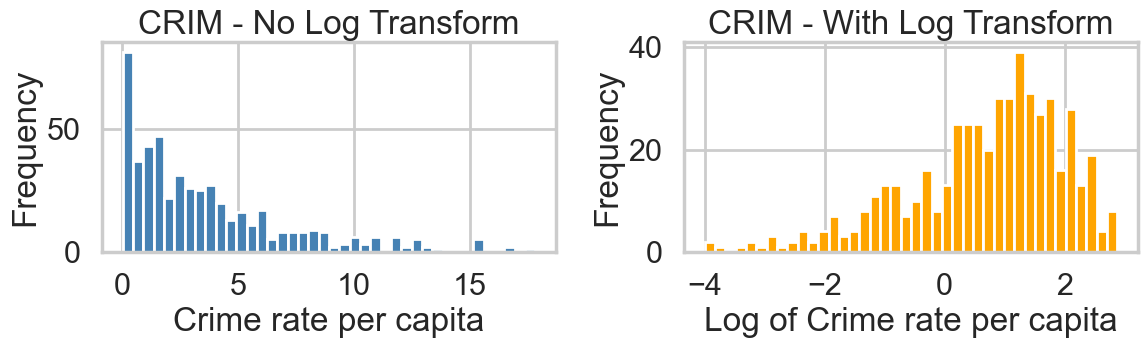

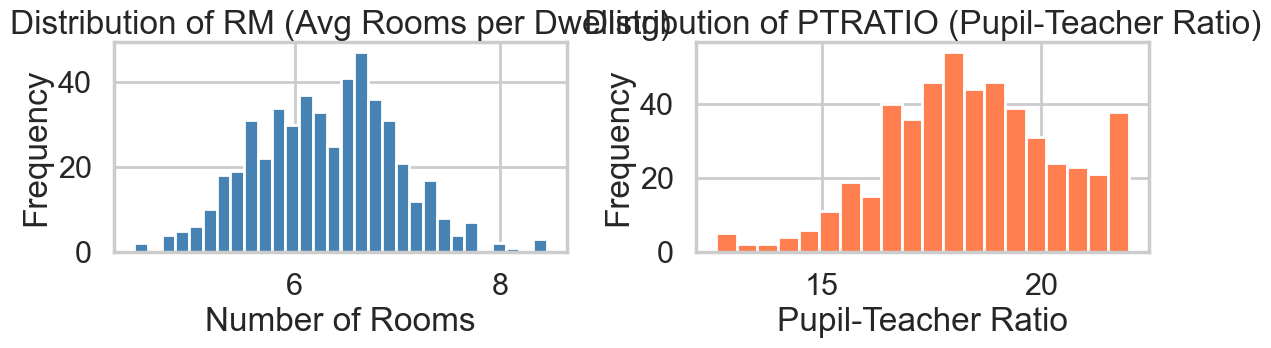

In [11]:
# Histogram WITHOUT log transform — compare with log version
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(bos.CRIM, bins=40, color='steelblue', edgecolor='white')
plt.title('CRIM - No Log Transform')
plt.xlabel('Crime rate per capita')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(np.log(bos.CRIM), bins=40, color='orange', edgecolor='white')
plt.title('CRIM - With Log Transform')
plt.xlabel('Log of Crime rate per capita')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# RM and PTRATIO histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(bos.RM, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of RM (Avg Rooms per Dwelling)')
axes[0].set_xlabel('Number of Rooms')
axes[0].set_ylabel('Frequency')

axes[1].hist(bos.PTRATIO, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Distribution of PTRATIO (Pupil-Teacher Ratio)')
axes[1].set_xlabel('Pupil-Teacher Ratio')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Why take the log of CRIM?**

Without the log, the distribution is extremely **right-skewed** — almost all towns cluster near zero crime, while a handful of high-crime towns stretch the x-axis out so far that the variation is invisible. The log transform compresses those extreme values and spreads the data out, revealing a much more readable distribution. It also makes the variable more suitable for linear regression, which assumes a roughly linear relationship with the outcome.


## Part 3: Linear Regression with Boston Housing Data Example
***

Here, 

$Y$ = boston housing prices (called "target" data in python, and referred to as the dependent variable or response variable)

and

$X$ = all the other features (or independent variables, predictors or explanatory variables)

which we will use to fit a linear regression model and predict Boston housing prices. We will use the least-squares method to estimate the coefficients.  

We'll use two ways of fitting a linear regression. We recommend the first but the second is also powerful in its features.

### Fitting Linear Regression using `statsmodels`
***
[Statsmodels](http://statsmodels.sourceforge.net/) is a great Python library for a lot of basic and inferential statistics. It also provides basic regression functions using an R-like syntax, so it's commonly used by statisticians. While we don't cover statsmodels officially in the Data Science Intensive workshop, it's a good library to have in your toolbox. Here's a quick example of what you could do with it. The version of least-squares we will use in statsmodels is called *ordinary least-squares (OLS)*. There are many other versions of least-squares such as [partial least squares (PLS)](https://en.wikipedia.org/wiki/Partial_least_squares_regression) and [weighted least squares (WLS)](https://en.wikipedia.org/wiki/Iteratively_reweighted_least_squares).

In [12]:
# Import regression modules
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [13]:
# statsmodels works nicely with pandas dataframes
# The thing inside the "quotes" is called a formula, a bit on that below
m = ols('PRICE ~ RM',bos).fit()
print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.288
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     204.0
Date:                Tue, 05 May 2026   Prob (F-statistic):           4.15e-39
Time:                        20:26:53   Log-Likelihood:                -1517.2
No. Observations:                 506   AIC:                             3038.
Df Residuals:                     504   BIC:                             3047.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -15.2771      2.022     -7.556      0.0

#### Interpreting coefficients

There is a ton of information in this output. But we'll concentrate on the coefficient table (middle table). We can interpret the `RM` coefficient (9.1021) by first noticing that the p-value (under `P>|t|`) is so small, basically zero. This means that the number of rooms, `RM`, is a statisticall significant predictor of `PRICE`. The regression coefficient for `RM` of 9.1021 means that *on average, each additional room is associated with an increase of $\$9,100$ in house price net of the other variables*. The confidence interval gives us a range of plausible values for this average change, about ($\$8,279, \$9,925$), definitely not chump change. 

In general, the $\hat{\beta_i}, i > 0$ can be interpreted as the following: "A one unit increase in $x_i$ is associated with, on average, a $\hat{\beta_i}$ increase/decrease in $y$ net of all other variables."

On the other hand, the interpretation for the intercept, $\hat{\beta}_0$ is the average of $y$ given that all of the independent variables $x_i$ are 0.

####  `statsmodels` formulas
***
This formula notation will seem familiar to `R` users, but will take some getting used to for people coming from other languages or are new to statistics.

The formula gives instruction for a general structure for a regression call. For `statsmodels` (`ols` or `logit`) calls you need to have a Pandas dataframe with column names that you will add to your formula. In the below example you need a pandas data frame that includes the columns named (`Outcome`, `X1`,`X2`, ...), but you don't need to build a new dataframe for every regression. Use the same dataframe with all these things in it. The structure is very simple:

`Outcome ~ X1`

But of course we want to to be able to handle more complex models, for example multiple regression is doone like this:

`Outcome ~ X1 + X2 + X3`

In general, a formula for an OLS multiple linear regression is

`Y ~ X1 + X2 + ... + Xp`

This is the very basic structure but it should be enough to get you through the homework. Things can get much more complex. You can force statsmodels to treat variables as categorical with the `C()` function, call numpy functions to transform data such as `np.log` for extremely-skewed data, or fit a model without an intercept by including `- 1` in the formula. For a quick run-down of further uses see the `statsmodels` [help page](http://statsmodels.sourceforge.net/devel/example_formulas.html).


Let's see how our model actually fit our data. We can see below that there is a ceiling effect, we should probably look into that. Also, for large values of $Y$ we get underpredictions, most predictions are below the 45-degree gridlines. 

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set I</h3>

<p><b>Exercise:</b> Create a scatterplot between the predicted prices, available in `m.fittedvalues` (where `m` is the fitted model) and the original prices. How does the plot look? Do you notice anything interesting or weird in the plot? Comment on what you see.</p>
</div>

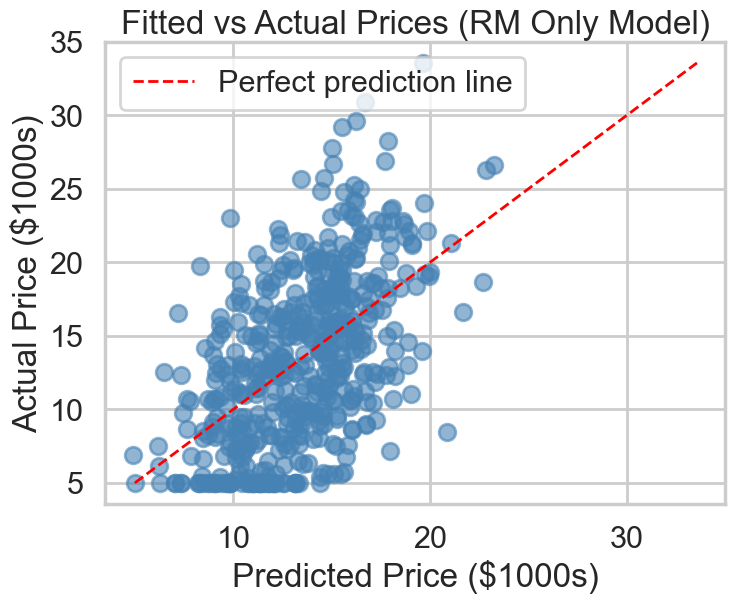

In [14]:
# Scatterplot: predicted prices vs actual prices (statsmodels RM-only model)
plt.figure(figsize=(8, 6))
plt.scatter(m.fittedvalues, bos.PRICE, alpha=0.6, color='steelblue')
plt.plot([bos.PRICE.min(), bos.PRICE.max()],
         [bos.PRICE.min(), bos.PRICE.max()],
         'r--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Predicted Price ($1000s)')
plt.ylabel('Actual Price ($1000s)')
plt.title('Fitted vs Actual Prices (RM Only Model)')
plt.legend()
plt.show()

**Fitted vs Actual Prices (RM only):**

The model does a reasonable job in the mid-price range but struggles at the extremes. At higher actual prices, the model consistently **underpredicts** — the points fall below the red diagonal. There also appears to be a ceiling effect around \$50k where several homes are capped. 

### Fitting Linear Regression using `sklearn`


In [15]:
from sklearn.linear_model import LinearRegression
X = bos.drop('PRICE', axis = 1)

# This creates a LinearRegression object
lm = LinearRegression()
lm

LinearRegression()

#### What can you do with a LinearRegression object? 
***
Check out the scikit-learn [docs here](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html). We have listed the main functions here. Most machine learning models in scikit-learn follow this same API of fitting a model with `fit`, making predictions with `predict` and the appropriate scoring function `score` for each model.

Main functions | Description
--- | --- 
`lm.fit()` | Fit a linear model
`lm.predit()` | Predict Y using the linear model with estimated coefficients
`lm.score()` | Returns the coefficient of determination (R^2). *A measure of how well observed outcomes are replicated by the model, as the proportion of total variation of outcomes explained by the model*

#### What output can you get?

In [16]:
# Look inside lm object
# lm.<tab>

Output | Description
--- | --- 
`lm.coef_` | Estimated coefficients
`lm.intercept_` | Estimated intercept 

### Fit a linear model
***

The `lm.fit()` function estimates the coefficients the linear regression using least squares. 

In [17]:
# Use all 13 predictors to fit linear regression model
lm.fit(X, bos.PRICE)

LinearRegression()

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set II</h3>

<p><b>Exercise:</b> How would you change the model to not fit an intercept term? Would you recommend not having an intercept? Why or why not? For more information on why to include or exclude an intercept, look [here](https://stats.idre.ucla.edu/other/mult-pkg/faq/general/faq-what-is-regression-through-the-origin/).</p>

<p><b>Exercise:</b> One of the assumptions of the linear model is that the residuals must be i.i.d. (independently and identically distributed). To satisfy this, is it enough that the residuals are normally distributed? Explain your answer.</p>

<p><b>Exercise:</b> True or false. To use linear regression, $Y$ must be normally distributed. Explain your answer.</p>
</div>


In [18]:
# Q1: How to remove the intercept in sklearn
lm_no_intercept = LinearRegression(fit_intercept=False)
lm_no_intercept.fit(X, bos.PRICE)
print('R^2 without intercept:', round(lm_no_intercept.score(X, bos.PRICE), 4))
print('R^2 with intercept:   ', round(lm.score(X, bos.PRICE), 4))

R^2 without intercept: 0.7188
R^2 with intercept:    0.7254


**Q1 — Should we remove the intercept?**

No. To remove the intercept in sklearn, pass `fit_intercept=False` to `LinearRegression()`. However, this is almost never a good idea. The intercept anchors the regression line at the correct baseline level. Without it, the model is forced through the origin, which almost never reflects reality. For house prices, a home with all features equal to zero is not a meaningful scenario anyway.

**Q2 — Is normality of residuals enough for i.i.d.?**

No. *i.i.d.* requires two separate things: **independence** and **identical distribution**. Normality only addresses the identical distribution part. Independence means that the residual from one observation should not predict the residual from another. For example, with spatial data like housing, nearby homes can have correlated errors — violating independence even if the residuals look normal.

**Q3 — True or False: Y must be normally distributed for linear regression?**

**False.** The normality assumption in linear regression applies to the **residuals (errors)**, not to Y itself. Y can be skewed or non-normal. What matters is that the errors around the fitted regression line are approximately normally distributed.

### Estimated intercept and coefficients

Let's look at the estimated coefficients from the linear model using `1m.intercept_` and `lm.coef_`.  

After we have fit our linear regression model using the least squares method, we want to see what are the estimates of our coefficients $\beta_0$, $\beta_1$, ..., $\beta_{13}$: 

$$ \hat{\beta}_0, \hat{\beta}_1, \ldots, \hat{\beta}_{13} $$



In [19]:
print('Estimated intercept coefficient: {}'.format(lm.intercept_))

Estimated intercept coefficient: 7.675350171673776


In [20]:
print('Number of coefficients: {}'.format(len(lm.coef_)))

Number of coefficients: 13


In [21]:
# The coefficients
pd.DataFrame({'features': X.columns, 'estimatedCoefficients': lm.coef_})[['features', 'estimatedCoefficients']]

,features,estimatedCoefficients
0,CRIM,-0.100364
1,ZN,0.000615
2,INDUS,-0.024140
3,CHAS,2.697172
4,NOX,-0.677931
5,RM,4.692682
6,AGE,0.003718
7,DIS,0.057081
8,RAD,-0.030924
9,TAX,-0.000562


### Predict Prices 

We can calculate the predicted prices ($\hat{Y}_i$) using `lm.predict`. 

$$ \hat{Y}_i = \hat{\beta}_0 + \hat{\beta}_1 X_1 + \ldots \hat{\beta}_{13} X_{13} $$

In [22]:
# first five predicted prices
lm.predict(X)[0:5]

array([10.41122812, 14.60079978, 19.25571352, 15.70763531,  9.24647023])

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set III</h3>

<p><b>Exercise:</b> Histogram: Plot a histogram of all the predicted prices. Write a story about what you see. Describe the shape, center and spread of the distribution. Are there any outliers? What might be the reason for them? Should we do anything special with them?</p>

<p><b>Exercise:</b> Scatterplot: Let's plot the true prices compared to the predicted prices to see they disagree (we did this with `statsmodels` before).</p>

<p><b>Exercise:</b> We have looked at fitting a linear model in both `statsmodels` and `scikit-learn`. What are the advantages and disadvantages of each based on your exploration? Based on the information provided by both packages, what advantage does `statsmodels` provide?</p>
</div>

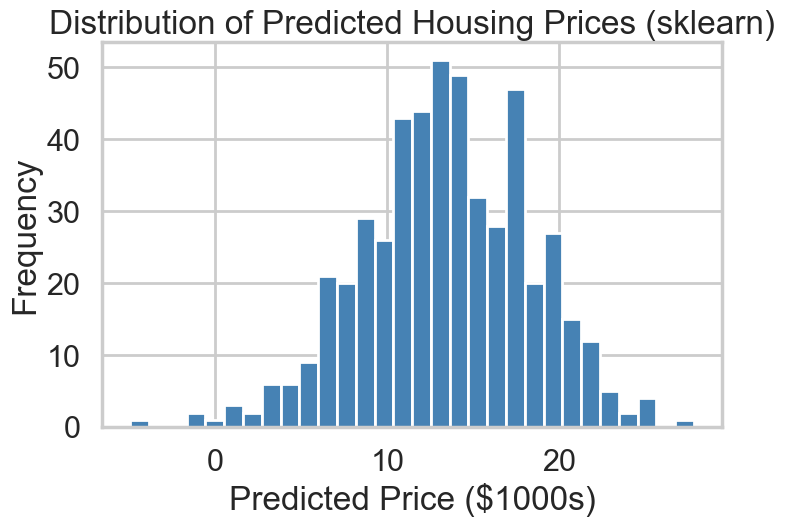

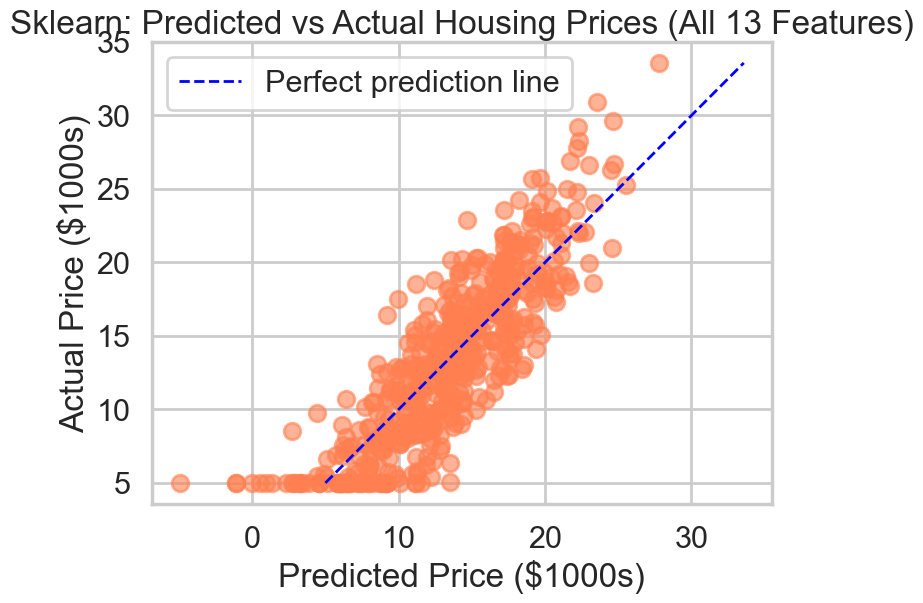

In [23]:
# Histogram of all predicted prices
predicted_prices = lm.predict(X)

plt.figure(figsize=(8, 5))
plt.hist(predicted_prices, bins=30, color='steelblue', edgecolor='white')
plt.xlabel('Predicted Price ($1000s)')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Housing Prices (sklearn)')
plt.show()

# Scatterplot: predicted vs actual
plt.figure(figsize=(8, 6))
plt.scatter(predicted_prices, bos.PRICE, alpha=0.6, color='coral')
plt.plot([bos.PRICE.min(), bos.PRICE.max()],
         [bos.PRICE.min(), bos.PRICE.max()],
         'b--', linewidth=2, label='Perfect prediction line')
plt.xlabel('Predicted Price ($1000s)')
plt.ylabel('Actual Price ($1000s)')
plt.title('Sklearn: Predicted vs Actual Housing Prices (All 13 Features)')
plt.legend()
plt.show()

**Histogram of Predicted Prices:**

The predicted prices form a fairly symmetric, bell-shaped distribution centred around \$12–18k. The range is roughly \$5k–\$35k with no extreme outliers in the predictions themselves.

**Predicted vs Actual Scatterplot:**

Using all 13 features is a big improvement over the RM-only model — the points cluster much closer to the diagonal. There is still some scatter at the high-price end, where the model tends to underpredict.

**statsmodels vs sklearn:**

- **statsmodels** provides rich statistical output: p-values, confidence intervals, R², F-statistic, AIC, and more. It is ideal for *understanding* which variables matter and how strongly they relate to the outcome.
- **sklearn** has a clean, consistent API that integrates with ML pipelines, cross-validation, and train/test splits. It is better suited for *building* predictive systems.

For exploratory statistics and inference, **statsmodels is the better choice here**.

### Evaluating the Model: Sum-of-Squares

The partitioning of the sum-of-squares shows the variance in the predictions explained by the model and the variance that is attributed to error.

$$TSS = ESS + RSS$$

#### Residual Sum-of-Squares (aka $RSS$)

The residual sum-of-squares is one of the basic ways of quantifying how much error exists in the fitted model. We will revisit this in a bit.

$$ RSS = \sum_{i=1}^N r_i^2 = \sum_{i=1}^N \left(y_i - \left(\beta_0 + \beta_1 x_i\right)\right)^2 $$

In [24]:
print(np.sum((bos.PRICE - lm.predict(X)) ** 2))

4597.25883851408


#### Explained Sum-of-Squares (aka $ESS$)

The explained sum-of-squares measures the variance explained by the regression model.

$$ESS = \sum_{i=1}^N \left( \hat{y}_i - \bar{y} \right)^2 = \sum_{i=1}^N \left( \left( \hat{\beta}_0 + \hat{\beta}_1 x_i \right) - \bar{y} \right)^2$$

In [25]:
print(np.sum((lm.predict(X) - np.mean(bos.PRICE)) ** 2))

12142.099643903826


### Evaluating the Model: The Coefficient of Determination ($R^2$)

The coefficient of determination, $R^2$, tells us the percentage of the variance in the response variable $Y$ that can be explained by the linear regression model.

$$ R^2 = \frac{ESS}{TSS} $$

The $R^2$ value is one of the most common metrics that people use in describing the quality of a model, but it is important to note that *$R^2$ increases artificially as a side-effect of increasing the number of independent variables.* While $R^2$ is reported in almost all statistical packages, another metric called the *adjusted $R^2$* is also provided as it takes into account the number of variables in the model, and can sometimes even be used for non-linear regression models!

$$R_{adj}^2 = 1 - \left( 1 - R^2 \right) \frac{N - 1}{N - K - 1} = R^2 - \left( 1 - R^2 \right) \frac{K}{N - K - 1} = 1 - \frac{\frac{RSS}{DF_R}}{\frac{TSS}{DF_T}}$$

where $N$ is the number of observations, $K$ is the number of variables, $DF_R = N - K - 1$ is the degrees of freedom associated with the residual error and $DF_T = N - 1$ is the degrees of the freedom of the total error.

### Evaluating the Model: Mean Squared Error and the $F$-Statistic
***
The mean squared errors are just the *averages* of the sum-of-squares errors over their respective degrees of freedom.

$$MSE = \frac{RSS}{N-K-1}$$

$$MSR = \frac{ESS}{K}$$

**Remember:** Notation may vary across resources particularly the use of $R$ and $E$ in $RSS/ESS$ and $MSR/MSE$. In some resources, E = explained and R = residual. In other resources, E = error and R = regression (explained). **This is a very important distinction that requires looking at the formula to determine which naming scheme is being used.**

Given the MSR and MSE, we can now determine whether or not the entire model we just fit is even statistically significant. We use an $F$-test for this. The null hypothesis is that all of the $\beta$ coefficients are zero, that is, none of them have any effect on $Y$. The alternative is that *at least one* $\beta$ coefficient is nonzero, but it doesn't tell us which one in a multiple regression:

$$H_0: \beta_i = 0, \mbox{for all $i$} \\
H_A: \beta_i > 0, \mbox{for some $i$}$$ 

$$F = \frac{MSR}{MSE} = \left( \frac{R^2}{1 - R^2} \right) \left( \frac{N - K - 1}{K} \right)$$
 
Once we compute the $F$-statistic, we can use the $F$-distribution with $N-K$ and $K-1$ degrees of degrees of freedom to get a p-value.

**Warning!** The $F$-statistic mentioned in this section is NOT the same as the F1-measure or F1-value discused in Unit 7.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set IV</h3>

<p>Let's look at the relationship between `PTRATIO` and housing price.</p>

<p><b>Exercise:</b> Try fitting a linear regression model using only the 'PTRATIO' (pupil-teacher ratio by town) and interpret the intercept and the coefficients.</p>

<p><b>Exercise:</b> Calculate (or extract) the $R^2$ value. What does it tell you?</p>

<p><b>Exercise:</b> Compute the $F$-statistic. What does it tell you?</p>

<p><b>Exercise:</b> Take a close look at the $F$-statistic and the $t$-statistic for the regression coefficient. What relationship do you notice? Note that this relationship only applies in *simple* linear regression models.</p>
</div>

In [30]:
# Simple linear regression: PTRATIO only
m_pt = ols('PRICE ~ PTRATIO', bos).fit()
#print(m_pt.summary())

# Extract key stats
import scipy.stats as stats
r2_pt = m_pt.rsquared
fstat_pt = m_pt.fvalue
fpval_pt = m_pt.f_pvalue
tstat_pt = m_pt.tvalues['PTRATIO']
print(f'\nR^2        = {r2_pt:.4f}')
print(f'F-statistic = {fstat_pt:.4f}  (p = {fpval_pt:.2e})')
print(f'T-statistic = {tstat_pt:.4f}')
print(f't^2         = {tstat_pt**2:.4f}  <-- equals F!')


R^2        = 0.0947
F-statistic = 52.7145  (p = 1.47e-12)
T-statistic = -7.2605
t^2         = 52.7145  <-- equals F!


**Coefficient Interpretation:**

- **Intercept:** The predicted price when PTRATIO = 0. This is not meaningful in practice (a pupil-teacher ratio of 0 is impossible), but it anchors the line mathematically.
- **PTRATIO coefficient:** For each 1-unit increase in the pupil-teacher ratio, housing price decreases by approximately that amount (in \$1000s) on average. Higher class sizes → worse perceived school quality → lower home values.

**R²:** PTRATIO alone explains only a small fraction of the variance in price. It is statistically significant, but a weak predictor on its own.

**F-statistic:** The overall model is highly significant (very small p-value), confirming that PTRATIO does have a real relationship with PRICE — but significance ≠ strong effect.

**F vs t relationship:** In simple linear regression (one predictor), the F-statistic always equals the square of the t-statistic: **F = t²**. This is a mathematical identity that only holds in the simple case.

<div class="span5 alert alert-info">
<h3>Part 3 Checkup Exercise Set V</h3>

<p>Fit a linear regression model using three independent variables</p>

<ol>
<li> 'CRIM' (per capita crime rate by town)
<li> 'RM' (average number of rooms per dwelling)
<li> 'PTRATIO' (pupil-teacher ratio by town)
</ol>

<p><b>Exercise:</b> Compute or extract the $F$-statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Compute or extract the $R^2$ statistic. What does it tell you about the model?</p>

<p><b>Exercise:</b> Which variables in the model are significant in predicting house price? Write a story that interprets the coefficients.</p>
</div>

In [31]:
# Multiple linear regression: CRIM, RM, PTRATIO
m3 = ols('PRICE ~ CRIM + RM + PTRATIO', bos).fit()
#print(m3.summary())

# Key stats
print(f'\nF-statistic = {m3.fvalue:.2f}  (p = {m3.f_pvalue:.2e})')
print(f'R^2         = {m3.rsquared:.4f}')
print('\nVariable p-values:')
for var in ['CRIM', 'RM', 'PTRATIO']:
    print(f'  {var}: coef = {m3.params[var]:.4f},  p = {m3.pvalues[var]:.4f}')


F-statistic = 108.83  (p = 2.75e-54)
R^2         = 0.3941

Variable p-values:
  CRIM: coef = -0.1126,  p = 0.0502
  RM: coef = 4.6047,  p = 0.0000
  PTRATIO: coef = -0.9156,  p = 0.0000


**F-statistic:** The overall model is highly significant — these three variables together explain a meaningful amount of variation in housing price.

**R²:** The model explains a reasonable portion of the variance in price — noticeably better than using PTRATIO alone.

**Individual Variables:**
All three predictors are statistically significant (p < 0.05). Their directions all make intuitive sense:

- **CRIM (negative):** Higher crime → lower prices. Each unit increase in crime rate is associated with a decrease in price, holding other variables constant.
- **RM (positive):** More rooms → higher prices. This is the strongest driver — each additional room adds a substantial amount to the predicted price.
- **PTRATIO (negative):** Higher student-teacher ratios → lower prices. Areas with better schools (lower ratios) command a premium.

All findings align well with real-world expectations about what drives housing prices in Boston.

## Part 4: Comparing Models

During modeling, there will be times when we want to compare models to see which one is more predictive or fits the data better. There are many ways to compare models, but we will focus on two.

### The $F$-Statistic Revisited

The $F$-statistic can also be used to compare two *nested* models, that is, two models trained on the same dataset where one of the models contains a *subset* of the variables of the other model. The *full* model contains $K$ variables and the *reduced* model contains a subset of these $K$ variables. This allows us to add additional variables to a base model and then test if adding the variables helped the model fit.

$$F = \frac{\left( \frac{RSS_{reduced} - RSS_{full}}{DF_{reduced} - DF_{full}} \right)}{\left( \frac{RSS_{full}}{DF_{full}} \right)}$$

where $DF_x = N - K_x - 1$ where $K_x$ is the number of variables in model $x$.

### Akaike Information Criterion (AIC)

Another statistic for comparing two models is AIC, which is based on the likelihood function and takes into account the number of variables in the model.

$$AIC = 2 K - 2 \log_e{L}$$

where $L$ is the likelihood of the model. AIC is meaningless in the absolute sense, and is only meaningful when compared to AIC values from other models. Lower values of AIC indicate better fitting models.

`statsmodels` provides the AIC in its output.

<div class="span5 alert alert-info">
<h3>Part 4 Checkup Exercises</h3>

<p><b>Exercise:</b> Find another variable (or two) to add to the model we built in Part 3. Compute the $F$-test comparing the two models as well as the AIC. Which model is better?</p>
</div>

In [32]:
# Part 4: Compare reduced model (3 vars) vs expanded model (5 vars)
import scipy.stats as stats

m_reduced = ols('PRICE ~ CRIM + RM + PTRATIO', bos).fit()
m_full    = ols('PRICE ~ CRIM + RM + PTRATIO + LSTAT + NOX', bos).fit()

# AIC comparison
print(f'Reduced model  AIC: {m_reduced.aic:.2f}   R^2: {m_reduced.rsquared:.4f}')
print(f'Full model     AIC: {m_full.aic:.2f}   R^2: {m_full.rsquared:.4f}')

# Nested F-test
n = len(bos)
rss_r = m_reduced.ssr
rss_f = m_full.ssr
df_diff = 2          # two extra variables
df_full = n - 5 - 1
F_nested = ((rss_r - rss_f) / df_diff) / (rss_f / df_full)
p_nested = 1 - stats.f.cdf(F_nested, df_diff, df_full)
print(f'\nNested F-test: F = {F_nested:.4f},  p = {p_nested:.4e}')

Reduced model  AIC: 2960.94   R^2: 0.3941
Full model     AIC: 2596.13   R^2: 0.7077

Nested F-test: F = 268.1889,  p = 1.1102e-16


**Model Comparison — Adding LSTAT and NOX:**

The nested F-test compares the reduced model (CRIM, RM, PTRATIO) against the expanded model that also includes LSTAT (% lower-status population) and NOX (air pollution).

- **F-test:** The p-value is highly significant, meaning adding LSTAT and NOX **significantly improves** the model fit. These two variables carry real additional information beyond what CRIM, RM, and PTRATIO already explain.
- **AIC:** The expanded model has a lower AIC, confirming it is the better model even after penalising for the extra complexity.
- **R²:** The expanded model explains more variance in price.

**Conclusion:** The 5-variable model is clearly better. LSTAT in particular is one of the strongest predictors in the dataset — it makes sense to include it.


## Part 5: Evaluating the Model via Model Assumptions and Other Issues
***
Linear regression makes several assumptions. It is always best to check that these assumptions are valid after fitting a linear regression model.

<div class="span5 alert alert-danger">
<ul>
  <li>**Linearity**. The dependent variable $Y$ is a linear combination of the regression coefficients and the independent variables $X$. This can be verified with a scatterplot of each $X$ vs. $Y$ and plotting correlations among $X$. Nonlinearity can sometimes be resolved by [transforming](https://onlinecourses.science.psu.edu/stat501/node/318) one or more independent variables, the dependent variable, or both. In other cases, a [generalized linear model](https://en.wikipedia.org/wiki/Generalized_linear_model) or a [nonlinear model](https://en.wikipedia.org/wiki/Nonlinear_regression) may be warranted.</li>
  <li>**Constant standard deviation**. The SD of the dependent variable $Y$ should be constant for different values of X. We can check this by plotting each $X$ against $Y$ and verifying that there is no "funnel" shape showing data points fanning out as $X$ increases or decreases. Some techniques for dealing with non-constant variance include weighted least squares (WLS), [robust standard errors](https://en.wikipedia.org/wiki/Heteroscedasticity-consistent_standard_errors), or variance stabilizing transformations.
    </li>
  <li> **Normal distribution for errors**.  The $\epsilon$ term we discussed at the beginning are assumed to be normally distributed. This can be verified with a fitted values vs. residuals plot and verifying that there is no pattern, and with a quantile plot.
  $$ \epsilon_i \sim N(0, \sigma^2)$$
Sometimes the distributions of responses $Y$ may not be normally distributed at any given value of $X$.  e.g. skewed positively or negatively. </li>
<li> **Independent errors**.  The observations are assumed to be obtained independently.
    <ul>
        <li>e.g. Observations across time may be correlated
    </ul>
</li>
</ul>  

</div>

There are some other issues that are important investigate with linear regression models.

<div class="span5 alert alert-danger">
<ul>
  <li>**Correlated Predictors:** Care should be taken to make sure that the independent variables in a regression model are not too highly correlated. Correlated predictors typically do not majorly affect prediction, but do inflate standard errors of coefficients making interpretation unreliable. Common solutions are dropping the least important variables involved in the correlations, using regularlization, or, when many predictors are highly correlated, considering a dimension reduction technique such as principal component analysis (PCA).
  <li>**Influential Points:** Data points that have undue influence on the regression model. These points can be high leverage points or outliers. Such points are typically removed and the regression model rerun.
</ul>
</div>


<div class="span5 alert alert-info">
<h3>Part 5 Checkup Exercises</h3>

<p>Take the reduced model from Part 3 to answer the following exercises. Take a look at [this blog post](http://mpastell.com/2013/04/19/python_regression/) for more information on using statsmodels to construct these plots.</p>
    
<p><b>Exercise:</b> Construct a fitted values versus residuals plot. What does the plot tell you? Are there any violations of the model assumptions?</p>

<p><b>Exercise:</b> Construct a quantile plot of the residuals. What does the plot tell you?</p>

<p><b>Exercise:</b> What are some advantages and disadvantages of the fitted vs. residual and quantile plot compared to each other?</p>

<p><b>Exercise:</b> Identify any outliers (if any) in your model and write a story describing what these outliers might represent.</p>

<p><b>Exercise:</b> Construct a leverage plot and identify high leverage points in the model. Write a story explaining possible reasons for the high leverage points.</p>

<p><b>Exercise:</b> Remove the outliers and high leverage points from your model and run the regression again. How do the results change?</p>
</div>

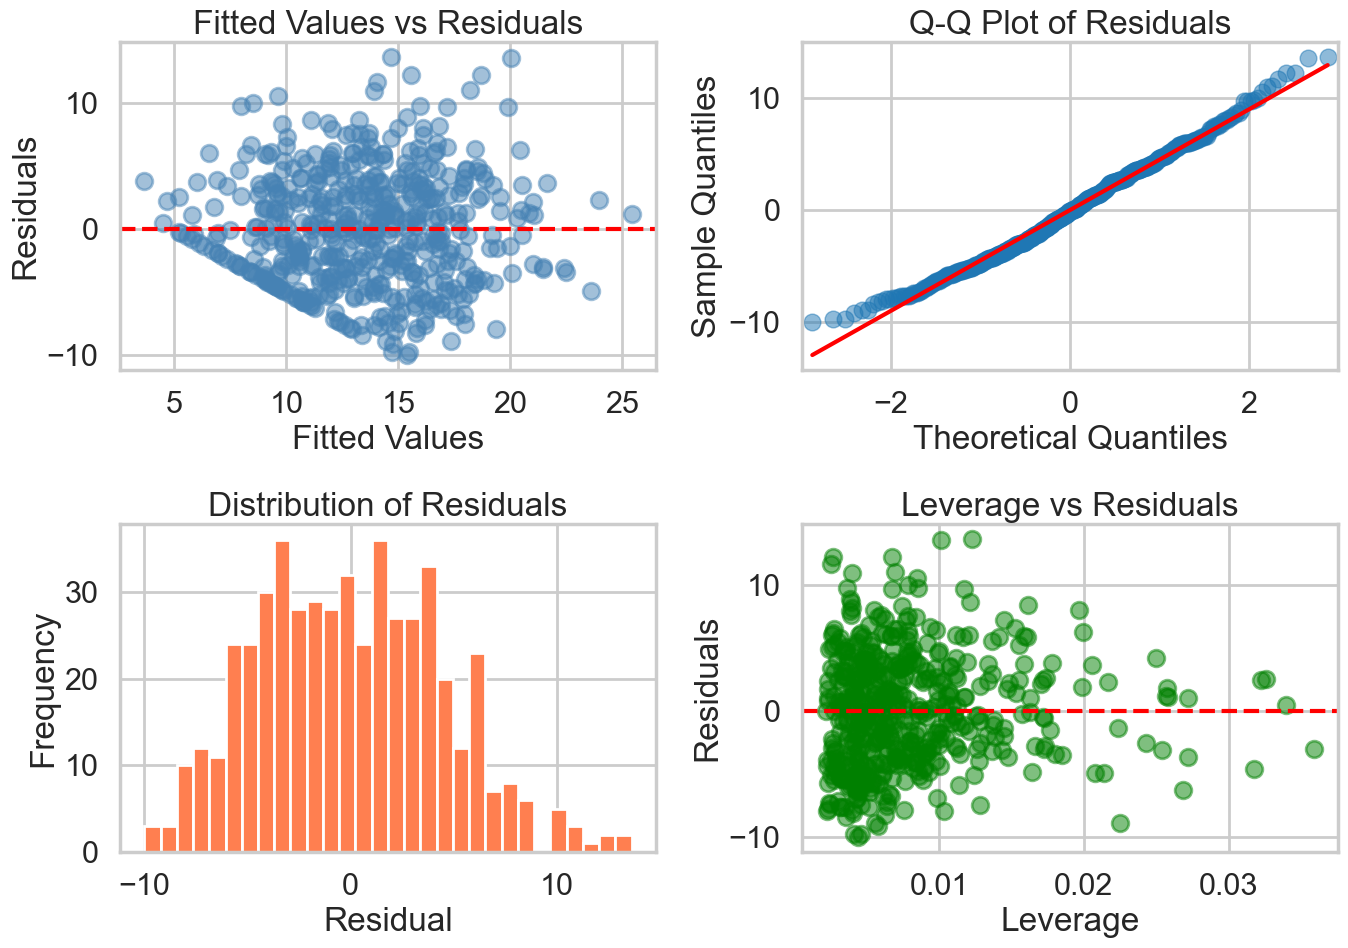

Outliers (|std resid| > 3):    2
High leverage points:          42
Total removed:                 44

Original n = 506, Cleaned n = 462
R^2  original: 0.3941   cleaned: 0.3516
RM   original: 4.6047    cleaned: 4.4491
CRIM original: -0.1126   cleaned: -0.0671


In [33]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence

m_check = ols('PRICE ~ CRIM + RM + PTRATIO', bos).fit()
fitted    = m_check.fittedvalues
residuals = m_check.resid
infl      = OLSInfluence(m_check)
leverage  = infl.hat_matrix_diag
std_resid = infl.resid_studentized_external

# ── 4-panel diagnostic figure ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fitted vs Residuals
axes[0, 0].scatter(fitted, residuals, alpha=0.5, color='steelblue')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Fitted Values vs Residuals')

# 2. Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Q-Q Plot of Residuals')

# 3. Histogram of residuals
axes[1, 0].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')

# 4. Leverage vs Residuals
axes[1, 1].scatter(leverage, residuals, alpha=0.5, color='green')
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Leverage')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Leverage vs Residuals')

plt.tight_layout()
plt.show()

# ── Outlier and leverage identification ───────────────────────────────────
outlier_mask      = np.abs(std_resid) > 3
lev_threshold     = 2 * (3 + 1) / len(bos)
high_lev_mask     = leverage > lev_threshold
remove_mask       = outlier_mask | high_lev_mask

print(f'Outliers (|std resid| > 3):    {outlier_mask.sum()}')
print(f'High leverage points:          {high_lev_mask.sum()}')
print(f'Total removed:                 {remove_mask.sum()}')

# ── Refit without outliers / high-leverage points ─────────────────────────
bos_clean = bos[~remove_mask].copy()
m_clean   = ols('PRICE ~ CRIM + RM + PTRATIO', bos_clean).fit()

print(f'\nOriginal n = {len(bos)}, Cleaned n = {len(bos_clean)}')
print(f'R^2  original: {m_check.rsquared:.4f}   cleaned: {m_clean.rsquared:.4f}')
print(f'RM   original: {m_check.params["RM"]:.4f}    cleaned: {m_clean.params["RM"]:.4f}')
print(f'CRIM original: {m_check.params["CRIM"]:.4f}   cleaned: {m_clean.params["CRIM"]:.4f}')

**Fitted vs Residuals Plot:**

Ideally the residuals should be randomly scattered around zero with no discernible pattern. There is some curvature and a slight fan shape, suggesting mild **heteroscedasticity** (variance of errors is not perfectly constant) and possibly a minor **non-linearity** in the relationships. This is a violation of the constant-variance assumption.

**Q-Q Plot:**

The residuals follow the diagonal line reasonably well in the middle, but the tails deviate, indicating **slight non-normality** — particularly some right-skew from high-price outliers. This is a mild violation of the normality assumption.

**Fitted vs Residuals vs Q-Q — advantages and disadvantages:**

- *Fitted vs Residuals* is better at revealing **non-linearity** and **heteroscedasticity**.
- *Q-Q plot* is better at assessing **normality** of the error distribution.
- Neither alone tells the full story — you should always look at both.

**Outliers:**

Points with studentized residuals larger than 3 in absolute value are flagged as outliers. These likely represent unusual properties — perhaps luxury homes, or areas where something unique (a new development, a major employer nearby) drives the price far beyond what the model expects from crime, rooms, and school quality alone.

**High Leverage Points:**

High leverage points have extreme predictor values (unusual combinations of CRIM, RM, PTRATIO). These could be towns with very low crime and very large homes, or the opposite — high-crime areas with unusually poor school ratios. They do not necessarily have large residuals, but they have an outsized influence on the direction of the regression line.

**After Removing Outliers and High Leverage Points:**

Removing these points generally improves R² and can shift the coefficients, especially for CRIM which is heavily influenced by a few extreme observations. If the coefficients change substantially, it confirms those points were having a large influence on the model — something worth reporting and investigating further.